# DELTA DIY MRI Workshop — Running `.seq` Files in MRI4ALL

A Pulseq `.seq` file is a **vendor-neutral description of an MRI sequence**: RF pulses,
gradients, ADC windows and delays, written in physical units (Hz, Hz/m, seconds). It says
nothing about the scanner that will play it.

MRI4ALL turns that portable description into instructions for **MaRCoS** — the Magnetic
Resonance Control System running on the Red Pitaya. This notebook walks the whole path,
and everything except the final hardware step runs on a laptop with no scanner attached:

```
PyPulseq  ->  .seq file  ->  interpreter  ->  MaRCoS instructions  ->  MaRCoS  ->  raw data
 (build)      (portable)     (calibrate)      (tx0, rx0_en, grad_v*)   (hardware)
```

The step that matters, and the one this notebook spends most of its time on, is the
**interpreter**. That is where portable physical units become hardware DAC units, using
*your scanner's* calibration. Get the calibration wrong and the `.seq` is still perfectly
valid — it just plays the wrong pulse.

> **A note on the name `flocra`.** You will see it throughout: the interpreter lives in
> `console/external/flocra_pulseq/`, its class is `seq2flocra`, and its output is
> `_flo_dict`. FLOCRA was the predecessor FPGA project in the OCRA lineage; MaRCoS grew out
> of it and kept the instruction-dictionary interface, names included — `marcos_client`
> still calls the format a "flodict" and feeds it in via `expt.add_flodict(...)`. So the
> names are historical. **The hardware you are targeting is MaRCoS.**

**Why this matters for Adelpha:** Adelpha embeds this same console as its imaging sidecar.
Understanding what a `.seq` becomes here is what lets you reason about the Imaging Console
workspace, and about the digital twin's view of an acquisition.

**Prerequisites:** finish `01_setup_environment.ipynb` first and select the
`DIY MRI Workshop Python 3.11` kernel. No scanner or Red Pitaya is needed.

## Cell 1 — Locate the console and check which PyPulseq is active

This is one piece of setup that regularly trips people up, so it is worth doing
deliberately.

The interpreter lives at `console/external/flocra_pulseq/`, so `console/` has to be on
`sys.path`. But `console/` *also* contains a vendored `pypulseq/` directory. If you put
`console/` at the **front** of `sys.path`, that vendored copy shadows the PyPulseq you
installed in Cell 4 of notebook 01 — and the vendored copy cannot read Pulseq v1.3.1 files
written by the MATLAB toolbox.

So: **append** `console/` rather than inserting it. This cell does that and then reports
which PyPulseq actually won, so you are never guessing.

It also sets `MRI4ALL_BASE`. The console logs to `/opt/mri4all` on a real scanner install,
which you almost certainly cannot write to on a laptop; this variable is the supported
override for development checkouts.

In [5]:
# Cell 1 — Locate the console, set a writable base path, import the toolchain

import os
import sys
from pathlib import Path

print("Cell 1 — Environment and imports")
print("--------------------------------")

# Find the repository root by walking up until we see a `console` directory.
here = Path.cwd().resolve()
repo_root = None
for candidate in [here, *here.parents]:
    if (candidate / "console" / "external" / "flocra_pulseq").is_dir():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError(
        "Could not find the adelpha repo root from " + str(here) + ".\n"
        "Run this notebook from console/notebooks/ inside the repository."
    )

console_dir = repo_root / "console"
print("Repo root  :", repo_root)
print("Console    :", console_dir)

# The console logs under MRI4ALL_BASE; /opt/mri4all is not writable on a laptop.
work_dir = Path.cwd() / "seq_runner_output"
work_dir.mkdir(exist_ok=True)
os.environ.setdefault("MRI4ALL_BASE", str(work_dir / "mri4all"))
(Path(os.environ["MRI4ALL_BASE"]) / "logs").mkdir(parents=True, exist_ok=True)
print("MRI4ALL_BASE:", os.environ["MRI4ALL_BASE"])
print("Output dir  :", work_dir)

# APPEND, do not insert: keeps the installed PyPulseq ahead of console/pypulseq.
if str(console_dir) not in sys.path:
    sys.path.append(str(console_dir))

import numpy as np
import matplotlib.pyplot as plt
import pypulseq as pp
from external.flocra_pulseq.interpreter_pp import seq2flocra

from importlib.metadata import version as _pkg_version

pp_path = Path(pp.__file__).parent
vendored = console_dir / "pypulseq"

print("\nPyPulseq in use:", pp_path)
if pp_path == vendored:
    print("  NOTE: this is the VENDORED copy in console/pypulseq.")
    print("  It cannot read Pulseq v1.3.1 files written by the MATLAB toolbox (Cell 9).")
else:
    try:
        print("  Installed PyPulseq version:", _pkg_version("pypulseq"))
    except Exception:
        pass
    print("  PASS: using the installed PyPulseq, not the vendored copy.")

print("\nseq2flocra imported from:", Path(seq2flocra.__module__.replace('.', '/')).name)
print("PASS: MRI4ALL sequence toolchain is importable with no scanner attached.")

Cell 1 — Environment and imports
--------------------------------
Repo root  : /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha
Console    : /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console
MRI4ALL_BASE: /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/notebooks/seq_runner_output/mri4all
Output dir  : /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/notebooks/seq_runner_output

PyPulseq in use: /home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/pypulseq
  Installed PyPulseq version: 1.4.2.post1
  PASS: using the installed PyPulseq, not the vendored copy.

seq2flocra imported from: interpreter_pp
PASS: MRI4ALL sequence toolchain is importable with no scanner attached.


## Cell 2 — The scanner calibration

These four numbers are the entire bridge between a portable `.seq` and one particular
scanner. They are **not** part of the `.seq` file:

| Constant | Meaning | Used for |
| --- | --- | --- |
| `LARMOR_FREQ` | Larmor / local-oscillator frequency, MHz | Sets the transmit and receive centre frequency |
| `RF_MAX` | RF amplitude at full DAC scale, Hz | Divides RF amplitudes into DAC units |
| `GX/GY/GZ_MAX` | Gradient amplitude at full DAC scale, Hz/m | Divides gradient amplitudes into DAC units |
| `CLK_FREQ` | FPGA clock, MHz | Converts times into clock ticks |

On a real scanner these come from `console/external/seq/adjustments_acq/config.py`, which
reads the JSON written by the console's adjustment scans (the frequency, RF-amplitude and
shim calibrations). That file needs a configured scanner install to import, so this cell
tries it and falls back to representative values when it isn't available.

Importing that config also drags in the console's sequence registry, which emits a
wall of harmless "circular import" warnings; the cell silences those so the numbers stay
readable.

The fallbacks are fine for this notebook — nothing here reaches hardware — but on a real
system **an out-of-date calibration is the usual cause of a sequence that plays but
produces nothing.** The `.seq` is not the thing to suspect first.

In [6]:
# Cell 2 — Load the scanner calibration, or fall back to representative values

print("Cell 2 — Scanner calibration")
print("----------------------------")

calibration_source = "fallback defaults (no configured scanner install)"

# Importing the console config pulls in the sequence registry, and each sequence
# module re-imports the half-initialised config. That is harmless, but it emits a
# wall of "circular import" warnings. Quiet them so the calibration is readable.
import logging

logging.disable(logging.WARNING)
try:
    import external.seq.adjustments_acq.config as cfg

    LARMOR_FREQ_MHZ = float(cfg.LARMOR_FREQ)
    RF_MAX_HZ = float(cfg.RF_MAX)
    GX_MAX_HZ_M = float(cfg.GX_MAX)
    GY_MAX_HZ_M = float(cfg.GY_MAX)
    GZ_MAX_HZ_M = float(cfg.GZ_MAX)
    calibration_source = "console adjustment config (live scanner values)"
except Exception as exc:
    # Representative low-field values; adjust to your own system before scanning.
    LARMOR_FREQ_MHZ = 15.58
    RF_MAX_HZ = 5.0e3
    GX_MAX_HZ_M = GY_MAX_HZ_M = GZ_MAX_HZ_M = 1.5e6
    print("Could not read the scanner config (" + type(exc).__name__ + ").")
finally:
    logging.disable(logging.NOTSET)

CLK_FREQ_MHZ = 122.88  # Red Pitaya FPGA clock

print("Source:", calibration_source)
print()
print(f"  LARMOR_FREQ : {LARMOR_FREQ_MHZ:10.4f} MHz")
print(f"  RF_MAX      : {RF_MAX_HZ:10.1f} Hz      (RF amplitude at DAC full scale)")
print(f"  GX_MAX      : {GX_MAX_HZ_M:10.1f} Hz/m")
print(f"  GY_MAX      : {GY_MAX_HZ_M:10.1f} Hz/m")
print(f"  GZ_MAX      : {GZ_MAX_HZ_M:10.1f} Hz/m")
print(f"  CLK_FREQ    : {CLK_FREQ_MHZ:10.2f} MHz     (FPGA clock)")
print()
print("None of these appear in the .seq file. Swap the scanner, keep the .seq,")
print("change these numbers -- that is the whole point of a portable sequence format.")

Cell 2 — Scanner calibration
----------------------------
Source: console adjustment config (live scanner values)

  LARMOR_FREQ :    15.5200 MHz
  RF_MAX      :    10000.0 Hz      (RF amplitude at DAC full scale)
  GX_MAX      :  8000000.0 Hz/m
  GY_MAX      :  9000000.0 Hz/m
  GZ_MAX      : 10000000.0 Hz/m
  CLK_FREQ    :     122.88 MHz     (FPGA clock)

None of these appear in the .seq file. Swap the scanner, keep the .seq,
change these numbers -- that is the whole point of a portable sequence format.


## Cell 3 — Build a 1D spin echo with PyPulseq

This mirrors `console/sequences/common/make_se_1D.py`, which is the real 1D spin-echo
projection the console ships — same event order, same delay arithmetic — trimmed to one
average so the output stays readable.

The `pp.Opts` raster times are the part to pay attention to. `rf_raster_time`,
`grad_raster_time` and `block_duration_raster` must match what the interpreter and MaRCoS
expect; timing that is not on the raster grid is the most common reason `check_timing()`
fails in Cell 4.

The sequence is five events plus a TR delay:

1. 90° excitation
2. readout prephaser (dephases by half the readout area)
3. delay `tau1`, to place the echo at `TE`
4. 180° refocusing
5. delay `tau2`
6. readout gradient played with the ADC open

In [7]:
# Cell 3 — Construct a 1D spin-echo sequence

import math

print("Cell 3 — Build the sequence")
print("---------------------------")

# --- Sequence parameters (edit these) --------------------------------------
TE = 20e-3        # s     echo time
TR = 500e-3       # s     repetition time
FOV = 0.20        # m     field of view
NX = 64           # -     base resolution
BW = 20e3         # Hz    readout bandwidth
RF_DURATION = 100e-6   # s
RISE_TIME = 250e-6     # s  gradient rise time
READOUT_CHANNEL = "x"
# ---------------------------------------------------------------------------

system = pp.Opts(
    max_grad=max(GX_MAX_HZ_M, GY_MAX_HZ_M, GZ_MAX_HZ_M),
    grad_unit="Hz/m",
    max_slew=1000,
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=20e-6,
    rf_raster_time=1e-6,          # must match the interpreter / MaRCoS raster
    grad_raster_time=10e-6,
    block_duration_raster=1e-6,
)

seq = pp.Sequence(system)

rf90 = pp.make_block_pulse(
    flip_angle=math.pi / 2, duration=RF_DURATION, delay=100e-6,
    system=system, use="excitation",
)
rf180 = pp.make_block_pulse(
    flip_angle=math.pi, duration=RF_DURATION, delay=100e-6,
    phase_offset=math.pi / 2, system=system, use="refocusing",
)

readout_time = NX / BW
delta_k = 1 / FOV

gx = pp.make_trapezoid(
    channel=READOUT_CHANNEL, flat_area=NX * delta_k, flat_time=readout_time,
    rise_time=RISE_TIME, system=system,
)
gx_pre = pp.make_trapezoid(
    channel=READOUT_CHANNEL, area=gx.area / 2, duration=0.5 * readout_time,
    rise_time=RISE_TIME, system=system,
)
adc = pp.make_adc(
    num_samples=2 * NX,           # 2x oversampling, as the console does
    duration=gx.flat_time, delay=gx.rise_time,
    phase_offset=np.pi / 2, system=system,
)

# Delays that place the echo exactly at TE, rounded onto the gradient raster.
tau1 = math.ceil(
    (TE / 2 - 0.5 * (pp.calc_duration(rf90) + pp.calc_duration(rf180))
     - pp.calc_duration(gx_pre)) / seq.grad_raster_time
) * seq.grad_raster_time
tau2 = math.ceil(
    (TE / 2 - 0.5 * (pp.calc_duration(rf180) + pp.calc_duration(gx)))
    / seq.grad_raster_time
) * seq.grad_raster_time
delay_tr = TR - TE - 0.5 * readout_time

for name, value in (("tau1", tau1), ("tau2", tau2), ("delay_TR", delay_tr)):
    if value < 0:
        raise ValueError(
            f"{name} is negative ({value*1e3:.3f} ms). TE is too short for these "
            "RF and gradient durations -- increase TE or shorten the readout."
        )

seq.add_block(rf90)
seq.add_block(gx_pre)
seq.add_block(pp.make_delay(tau1))
seq.add_block(rf180)
seq.add_block(pp.make_delay(tau2))
seq.add_block(gx, adc)          # readout gradient and ADC in the same block
seq.add_block(pp.make_delay(delay_tr))

print(f"  readout time     : {readout_time*1e3:8.3f} ms")
print(f"  tau1             : {tau1*1e3:8.3f} ms")
print(f"  tau2             : {tau2*1e3:8.3f} ms")
print(f"  delay_TR         : {delay_tr*1e3:8.3f} ms")
print(f"  gx amplitude     : {gx.amplitude:10.1f} Hz/m")
print(f"  gx_pre amplitude : {gx_pre.amplitude:10.1f} Hz/m  (higher: same area, less time)")
print(f"  RF 90 peak       : {rf90.signal.max():10.1f} Hz")
print(f"  RF 180 peak      : {rf180.signal.max():10.1f} Hz")
print("\nPASS: sequence constructed.")

Cell 3 — Build the sequence
---------------------------
  readout time     :    3.200 ms
  tau1             :    8.180 ms
  tau2             :    8.040 ms
  delay_TR         :  478.400 ms
  gx amplitude     :   100000.0 Hz/m
  gx_pre amplitude :   127777.8 Hz/m  (higher: same area, less time)
  RF 90 peak       :     2500.0 Hz
  RF 180 peak      :     5000.0 Hz

PASS: sequence constructed.


## Cell 4 — Validate the timing and write the `.seq` file

`check_timing()` is the gate to clear **before** worrying about hardware. It verifies every
block sits on the raster grid and that no event overruns its block. A sequence that fails
here will not play correctly no matter how good the calibration is.

The written file is plain text. The cell prints its head so you can see the structure:
`[VERSION]`, `[DEFINITIONS]`, then `[BLOCKS]` — one row per block, with columns indexing
into the shape tables that follow. That readability is the format's great virtue: a `.seq`
can be diffed, version-controlled, and inspected by eye.

In [8]:
# Cell 4 — Timing check and .seq export

print("Cell 4 — Validate and export")
print("----------------------------")

ok, error_report = seq.check_timing()
if ok:
    print("PASS: PyPulseq timing check passed.")
else:
    print("WARNING: timing check FAILED. The file will still be written, but do not")
    print("         expect it to play correctly. Errors:")
    for err in error_report:
        print("   ", err)

duration, num_blocks, event_count = seq.duration()
print(f"\n  duration : {duration:.6f} s")
print(f"  blocks   : {len(seq.block_events)}")

seq_path = work_dir / "demo_se_1d.seq"
seq.write(str(seq_path))
print(f"\nWrote {seq_path.name} ({seq_path.stat().st_size} bytes)")
print("Full path:", seq_path)

print("\nFirst 28 lines of the .seq file")
print("-------------------------------")
with open(seq_path) as fh:
    for i, line in enumerate(fh):
        if i >= 28:
            print("   ...")
            break
        print("   " + line.rstrip())

Cell 4 — Validate and export
----------------------------
PASS: PyPulseq timing check passed.

  duration : 0.500360 s
  blocks   : 7

Wrote demo_se_1d.seq (1527 bytes)
Full path: /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/notebooks/seq_runner_output/demo_se_1d.seq

First 28 lines of the .seq file
-------------------------------
   # Pulseq sequence file
   # Created by PyPulseq
   
   [VERSION]
   major 1
   minor 4
   revision 2
   
   [DEFINITIONS]
   AdcRasterTime 1e-07
   BlockDurationRaster 1e-06
   GradientRasterTime 1e-05
   RadiofrequencyRasterTime 1e-06
   TotalDuration 0.50036
   
   # Format of blocks:
   # NUM DUR RF  GX  GY  GZ  ADC  EXT
   [BLOCKS]
   1 220   1   0   0   0  0  0
   2 1600   0   1   0   0  0  0
   3 8180   0   0   0   0  0  0
   4 220   2   0   0   0  0  0
   5 8040   0   0   0   0  0  0
   6 3700   0   2   0   0  1  0
   7 478400   0   0   0   0  0  0
   
   # Format of RF events:
   # id amplitude mag_id phase_id time_shape_

## Cell 5 — Plot the sequence as PyPulseq sees it

This is the **vendor-neutral** view: physical units, no scanner involved. Compare it with
the plot in Cell 7, which is the same sequence after MRI4ALL has converted it into
hardware instructions.

The `%matplotlib inline` at the top is not boilerplate. Importing the console config in
Cell 2 pulls in `common.qtcompat.configure_headless()`, which forces
`matplotlib.use("Agg")` so the console can run without a display. That is correct for a
scanner, but in a notebook it means `plt.show()` silently draws nothing. Every plotting
cell here re-asserts the inline backend afterwards -- worth remembering whenever you plot
in a notebook that has imported console modules. Lining those two pictures up side by side is the point of the whole
notebook.

Cell 5 — PyPulseq sequence diagram
----------------------------------
RF / ADC / gradient events in Hz and Hz/m -- no scanner calibration applied.



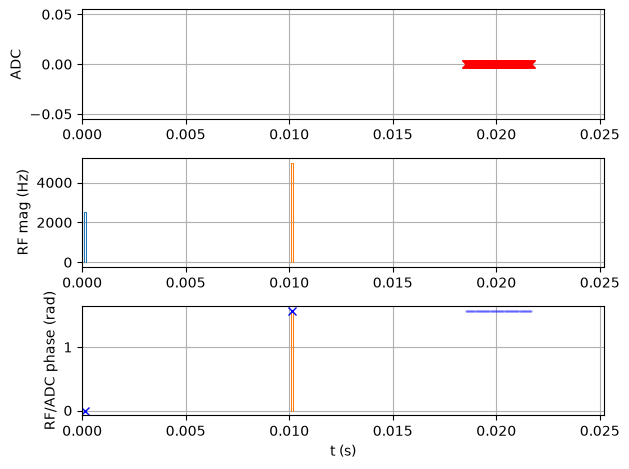

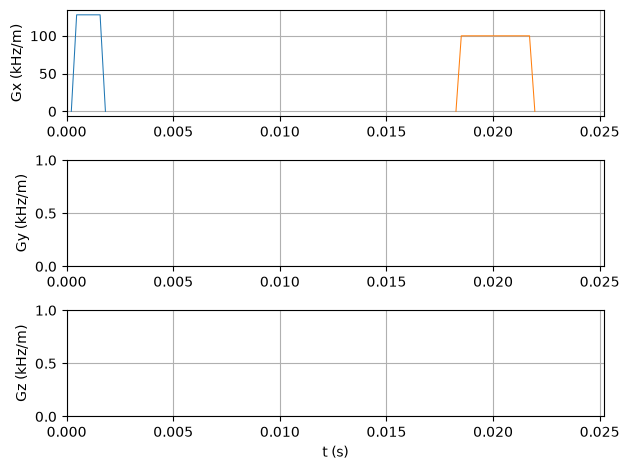

In [9]:
%matplotlib inline

# Cell 5 — Sequence diagram in physical units

print("Cell 5 — PyPulseq sequence diagram")
print("----------------------------------")
print("RF / ADC / gradient events in Hz and Hz/m -- no scanner calibration applied.\n")

try:
    seq.plot(time_range=(0, TE + readout_time + 2e-3))
except Exception as exc:
    print("seq.plot() failed (" + type(exc).__name__ + "):", exc)
    print("This is cosmetic only -- the .seq file itself is unaffected.")

## Cell 6 — Interpret the `.seq` into MaRCoS instructions

This is the MRI4ALL-specific step, and it is exactly what the console does before every
scan. The interpreter (`seq2flocra`, named for its FLOCRA heritage) reads the `.seq` and
produces a dictionary of **timed instruction streams**, one per MaRCoS hardware channel:

| Key | Hardware channel | Units |
| --- | --- | --- |
| `tx0` | RF transmit, complex envelope | DAC full scale, ±1 |
| `tx_gate` | RF amplifier blanking gate | 0 or 1 |
| `rx0_en` | Receive enable | 0 or 1 |
| `grad_vx`, `grad_vy`, `grad_vz` | Gradient outputs | DAC full scale, ±1 |
| `grad_vz2` | Second-order / shim channel | DAC full scale, ±1 |

Each value is `(times_us, amplitudes)` — timestamps in microseconds and the value to hold
from that timestamp until the next one.

**The rule to remember: amplitudes are normalised to ±1 full scale.** Anything outside
that range cannot be represented by the DAC. Cell 8 explores what that means in practice.

One practical constraint, found the hard way: **the interpreter requires at least one ADC
event.** A `.seq` containing only RF and delays raises
`AttributeError: 'list' object has no attribute 'shape'` inside
`block_events_to_amps_times()`. If you are debugging a pulse in isolation, add a short ADC
block.

In [10]:
# Cell 6 — .seq -> MaRCoS instruction dictionary

print("Cell 6 — Interpret the .seq for MaRCoS")
print("--------------------------------------")


def interpret_seq(path, rf_amp_max=None, verbose=True):
    """Run a .seq file through the interpreter and return the MaRCoS instructions."""
    psi = seq2flocra(
        center_freq=LARMOR_FREQ_MHZ * 1e6,
        rf_amp_max=RF_MAX_HZ if rf_amp_max is None else rf_amp_max,
        system=system,
        clk_freq=CLK_FREQ_MHZ,
        gx_max=GX_MAX_HZ_M,
        gy_max=GY_MAX_HZ_M,
        gz_max=GZ_MAX_HZ_M,
    )
    psi.load_seqfile(str(path))
    psi.block_events_to_amps_times()
    return psi._flo_dict


instructions = interpret_seq(seq_path)

print("Instruction channels produced:\n")
print(f"  {'channel':10s} {'points':>7s}  {'t_end (us)':>11s}  {'|amp| max':>10s}")
print("  " + "-" * 44)
for key, (times, amps) in instructions.items():
    amp = np.abs(np.asarray(amps))
    print(f"  {key:10s} {len(times):7d}  {times[-1]:11.1f}  {amp.max():10.4f}")

tx_peak = np.abs(np.asarray(instructions["tx0"][1])).max()
grad_peak = max(
    np.abs(np.asarray(instructions[k][1])).max()
    for k in ("grad_vx", "grad_vy", "grad_vz", "grad_vz2")
)

print()
print(f"Peak RF       : {tx_peak:.4f} of full scale")
print(f"Peak gradient : {grad_peak:.4f} of full scale")

for label, peak in (("RF", tx_peak), ("gradient", grad_peak)):
    if peak > 1.0:
        print(f"  WARNING: {label} exceeds DAC full scale by {peak:.2f}x -- hardware would clip.")
    else:
        print(f"  PASS: {label} fits within DAC full scale.")

Cell 6 — Interpret the .seq for MaRCoS
--------------------------------------
Instruction channels produced:

  channel     points   t_end (us)   |amp| max
  --------------------------------------------
  tx_gate          5     500360.0      1.0000
  tx0              6     500360.0      0.5000
  grad_vx          6     500360.0      0.0160
  grad_vy          2     500360.0      0.0000
  grad_vz          2     500360.0      0.0000
  grad_vz2         2     500360.0      0.0000
  rx0_en           4     500360.0      1.0000

Peak RF       : 0.5000 of full scale
Peak gradient : 0.0160 of full scale
  PASS: RF fits within DAC full scale.
  PASS: gradient fits within DAC full scale.


## Cell 7 — Plot the hardware instructions

This reproduces what `run_pulseq(..., plot_instructions=True)` draws inside the console, so
what you see here is what MaRCoS would be told to do — these streams are handed to
`marcos_client.Experiment` and uploaded to the Red Pitaya verbatim.

Read it against the Cell 5 plot. Same sequence, two coordinate systems: Cell 5 is in Hz and
Hz/m, this one is in DAC fractions on a real timebase in microseconds. The **shapes** must
match; if they don't, the interpreter or the raster settings are wrong. The **heights**
will not match, and should not — that difference is the calibration doing its job.

Cell 7 — MaRCoS instruction plot
--------------------------------


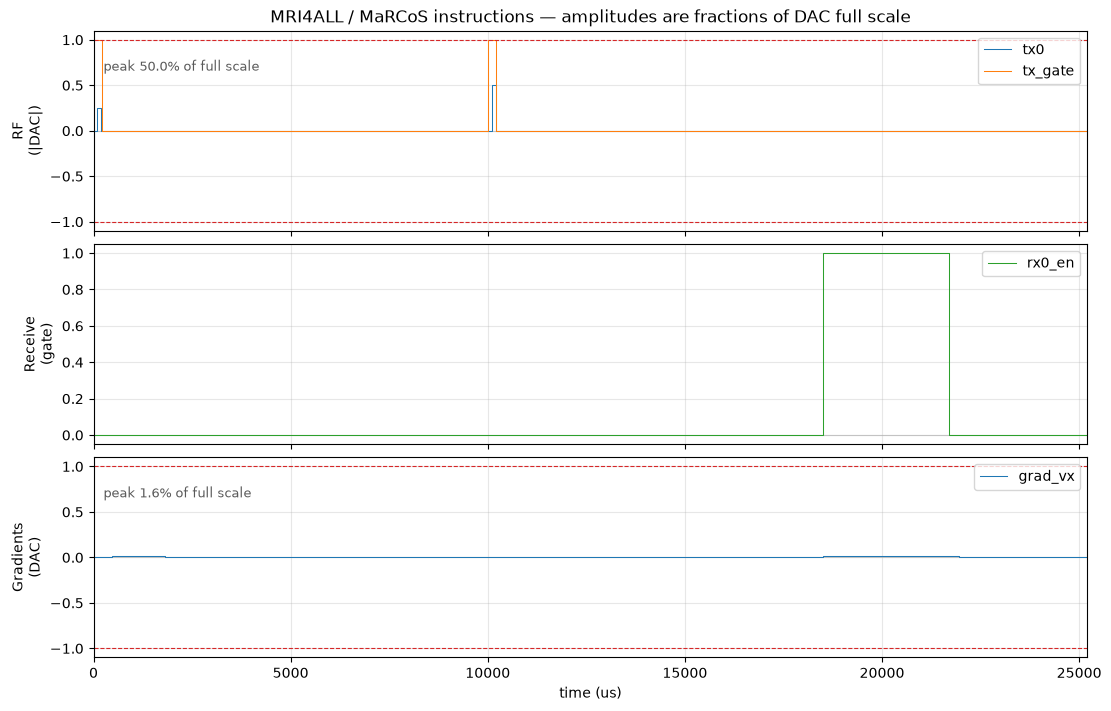

Red dashed lines mark DAC full scale (+/-1). Anything beyond them cannot be played.
Showing the active 25.2 ms of a 500 ms TR.
Set SHOW_FULL_TR = True to include the TR dead time.


In [11]:
%matplotlib inline

# Cell 7 — Plot the MaRCoS instruction streams

print("Cell 7 — MaRCoS instruction plot")
print("--------------------------------")

# The TR delay is ~25x longer than the active part of the sequence, so plotting the
# whole repetition squashes everything interesting into a sliver. Zoom to the active
# window by default; set SHOW_FULL_TR = True to see the dead time as well.
SHOW_FULL_TR = False
t_active_us = (TE + readout_time + 2e-3) * 1e6

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7), constrained_layout=True)

for key in ("tx0", "tx_gate"):
    if key in instructions:
        t, a = instructions[key]
        axes[0].step(t, np.abs(np.asarray(a)), where="post", label=key)
axes[0].set_ylabel("RF\n(|DAC|)")
axes[0].legend(loc="upper right")
axes[0].set_title("MRI4ALL / MaRCoS instructions — amplitudes are fractions of DAC full scale")

if "rx0_en" in instructions:
    t, a = instructions["rx0_en"]
    axes[1].step(t, np.asarray(a), where="post", label="rx0_en", color="tab:green")
axes[1].set_ylabel("Receive\n(gate)")
axes[1].legend(loc="upper right")

for key in ("grad_vx", "grad_vy", "grad_vz", "grad_vz2"):
    if key in instructions:
        t, a = instructions[key]
        arr = np.asarray(a)
        if np.abs(arr).max() > 0:      # skip flat, unused axes
            axes[2].step(t, arr, where="post", label=key)
axes[2].set_ylabel("Gradients\n(DAC)")
axes[2].set_xlabel("time (us)")
axes[2].legend(loc="upper right")

for ax in axes:
    ax.axhline(0, color="0.8", lw=0.8, zorder=0)
    ax.grid(alpha=0.3)

# Mark DAC full scale so out-of-range values are obvious.
for ax in (axes[0], axes[2]):
    ax.axhline(1.0, color="tab:red", ls="--", lw=0.8)
    ax.axhline(-1.0, color="tab:red", ls="--", lw=0.8)

# Annotate headroom: at low field the gradients often use a few percent of full scale.
axes[0].annotate(f"peak {tx_peak*100:.1f}% of full scale", xy=(0.01, 0.80),
                 xycoords="axes fraction", fontsize=9, color="0.35")
axes[2].annotate(f"peak {grad_peak*100:.1f}% of full scale", xy=(0.01, 0.80),
                 xycoords="axes fraction", fontsize=9, color="0.35")

if not SHOW_FULL_TR:
    axes[0].set_xlim(0, t_active_us)

plt.show()

print("Red dashed lines mark DAC full scale (+/-1). Anything beyond them cannot be played.")
if not SHOW_FULL_TR:
    print(f"Showing the active {t_active_us/1000:.1f} ms of a {seq.duration()[0]*1e3:.0f} ms TR.")
    print("Set SHOW_FULL_TR = True to include the TR dead time.")

## Cell 8 — Why the calibration is the thing that bites you

The `.seq` file does not change in this cell. Only `RF_MAX` changes — the number that says
*how much RF amplitude corresponds to full DAC scale*.

Watch the normalised RF amplitude move while the sequence stays identical. The 180° pulse
sets the peak, at twice the amplitude of the 90°.

This is the failure mode to internalise: **an RF calibration that is too low silently
demands more than the hardware can produce.** The sequence is valid, the timing check
passes, the scan runs — and the flip angles are wrong. On a real system you fix this by
rerunning the RF-amplitude adjustment scan, not by editing the sequence.

In [12]:
# Cell 8 — Sweep the RF calibration, keeping the sequence fixed

print("Cell 8 — RF calibration sweep (same .seq every time)")
print("---------------------------------------------------")
print()
print(f"  {'RF_MAX (Hz)':>12s}  {'peak RF (DAC)':>14s}   verdict")
print("  " + "-" * 52)

for rf_max_trial in (RF_MAX_HZ / 4, RF_MAX_HZ / 2, RF_MAX_HZ, RF_MAX_HZ * 2, RF_MAX_HZ * 4):
    flo = interpret_seq(seq_path, rf_amp_max=rf_max_trial)
    peak = np.abs(np.asarray(flo["tx0"][1])).max()
    if peak > 1.0:
        verdict = f"CLIPS ({peak:.2f}x full scale) -- flip angles wrong"
    elif peak < 0.1:
        verdict = "very low drive -- poor SNR, wasted dynamic range"
    else:
        verdict = "usable"
    marker = "  <-- calibrated value" if rf_max_trial == RF_MAX_HZ else ""
    print(f"  {rf_max_trial:12.0f}  {peak:14.4f}   {verdict}{marker}")

print()
print("The gradient axes behave the same way against GX/GY/GZ_MAX.")
print("Same .seq, different scanner calibration, completely different scan.")

2026-09-10 14:17:07,629 | unknown | WRN |  | RF amplitude exceeds RF max calibration


Cell 8 — RF calibration sweep (same .seq every time)
---------------------------------------------------

   RF_MAX (Hz)   peak RF (DAC)   verdict
  ----------------------------------------------------
          2500          2.0000   CLIPS (2.00x full scale) -- flip angles wrong
          5000          1.0000   usable
         10000          0.5000   usable  <-- calibrated value
         20000          0.2500   usable
         40000          0.1250   usable

The gradient axes behave the same way against GX/GY/GZ_MAX.
Same .seq, different scanner calibration, completely different scan.


## Cell 9 — Reading a `.seq` you did not write

Sequences arrive from elsewhere: colleagues, the Pulseq community, the MATLAB toolbox. The
console ships some of these — `console/external/seq/adjustments_acq/se_6.seq` is a spin
echo used by the adjustment scans, written by the MATLAB `mr` toolbox in **Pulseq v1.3.1**.

This is where the PyPulseq shadowing from Cell 1 has teeth. The vendored
`console/pypulseq` rejects that file with `Unsupported version_major: 1`; the installed
PyPulseq 1.4.2 reads it fine. The cell reports which one you have and behaves accordingly.

Notice in the output that this sequence drives **no gradients at all** — it is pure RF and
ADC, exactly what a frequency-calibration scan should be.

In [13]:
# Cell 9 — Load a .seq written by another toolchain

print("Cell 9 — Reading an externally authored .seq")
print("--------------------------------------------")

external_seq = console_dir / "external" / "seq" / "adjustments_acq" / "se_6.seq"
print("File:", external_seq)

if not external_seq.is_file():
    print("SKIP: file not present in this checkout.")
else:
    with open(external_seq) as fh:
        header = [next(fh).rstrip() for _ in range(8)]
    print("\nHeader:")
    for line in header:
        print("   " + line)

    try:
        external_instructions = interpret_seq(external_seq)
    except RuntimeError as exc:
        print("\nFAILED to read:", exc)
        print("\nThis is the vendored-PyPulseq problem described in Cell 1.")
        print("Restart the kernel and make sure console/ is APPENDED to sys.path,")
        print("so the installed PyPulseq 1.4.2 is used instead of console/pypulseq.")
    else:
        print("\nPASS: interpreted successfully.\n")
        print(f"  {'channel':10s} {'points':>7s}  {'|amp| max':>10s}")
        print("  " + "-" * 31)
        for key, (times, amps) in external_instructions.items():
            amp = np.abs(np.asarray(amps))
            print(f"  {key:10s} {len(times):7d}  {amp.max():10.4f}")

        gradients_used = any(
            np.abs(np.asarray(external_instructions[k][1])).max() > 0
            for k in ("grad_vx", "grad_vy", "grad_vz", "grad_vz2")
            if k in external_instructions
        )
        print()
        print("Gradients driven:", "yes" if gradients_used else "no (RF and ADC only)")

Cell 9 — Reading an externally authored .seq
--------------------------------------------
File: /home/jonathanmartin/Documents/postdoc-projects/DIY_MRI/adelpha/console/external/seq/adjustments_acq/se_6.seq

Header:
   # Pulseq sequence file
   # Created by MATLAB mr toolbox
   
   [VERSION]
   major 1
   minor 3
   revision 1
   

PASS: interpreted successfully.

  channel     points   |amp| max
  -------------------------------
  tx_gate         15      1.0000
  tx0             16      0.5000
  grad_vx          2      0.0000
  grad_vy          2      0.0000
  grad_vz          2      0.0000
  grad_vz2         2      0.0000
  rx0_en          14      1.0000

Gradients driven: no (RF and ADC only)


/home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/pypulseq/Sequence/read_seq.py:90: UserWarning: No BlockDurationRaster found in file. Using default of 1e-06.
  warnings.warn(f'No BlockDurationRaster found in file. Using default of {self.block_duration_raster}.')


## Cell 10 — The hardware step, and where the console takes over

Everything so far runs on a laptop. The remaining step needs a Red Pitaya, and the console
performs it with a single call:

```python
from external.seq.adjustments_acq.scripts import run_pulseq

rxd, rx_t = run_pulseq(
    seq_file=self.seq_file_path,                              # the .seq from Cell 4
    rf_center=scan_task.adjustment.rf.larmor_frequency,       # calibration, Cell 2
    tx_t=1, grad_t=10,                                        # raster times, us
    tx_warmup=100,
    shim_x=0.0, shim_y=0.0, shim_z=0.0,
    case_path=self.get_working_folder(),
)
```

`run_pulseq` does exactly what Cells 2, 6 and 7 did — reads the calibration, runs the
interpreter, produces the instruction dictionary — then adds the parts that need hardware:
it applies shim offsets, opens a `marcos_client.Experiment` to `marcos_server` on the Red
Pitaya (TCP port 11111), uploads the instructions, runs the experiment, and returns the raw
receive data `rxd` with its dwell time `rx_t`.

**How a console sequence is organised.** Every sequence in `console/sequences/` subclasses
`PulseqSequence` and implements the same two methods — see `console/sequences/FID.py` for
the shortest example:

- `calculate_sequence()` builds the `.seq` and writes it to `<working_folder>/seq/acq0.seq`.
  This is Cells 3 and 4.
- `run_sequence()` calls `run_pulseq()` on that file and hands the raw data to
  reconstruction. This is Cells 6 and 7, plus hardware.

So a new sequence is mostly the PyPulseq construction you already wrote in Cell 3, wrapped
in that class so the console's UI, parameter schema and scan queue can drive it.

**Where Adelpha fits.** Adelpha runs this console as its imaging sidecar. The Imaging
Console workspace registers an exam, the console executes `calculate_sequence()` and
`run_sequence()` as above, and the resulting data flows back into Adelpha's UI while the
digital twin observes the scanner state around it. The `.seq` file is the contract between
the sequence you designed and everything downstream of it.

In [14]:
# Cell 10 — What would happen next, on hardware (not executed here)

print("Cell 10 — The hardware step")
print("---------------------------")
print()
print("This notebook stops here. On a scanner, the console would call:")
print()
print("    rxd, rx_t = run_pulseq(")
print(f"        seq_file={seq_path.name!r},")
print(f"        rf_center={LARMOR_FREQ_MHZ},        # MHz, from the calibration")
print("        tx_t=1, grad_t=10,                  # us rasters")
print("        tx_warmup=100,")
print("        shim_x=0.0, shim_y=0.0, shim_z=0.0,")
print("    )")
print()
print("returning:")
print("    rxd  -- complex raw receive data, numpy array")
print(f"    rx_t -- receive dwell time in us  (this sequence acquires {2*NX} samples)")
print()

expected_duration = seq.duration()[0]
print(f"Expected scan duration for one average: {expected_duration:.3f} s")
print()
print("Artifacts written by this notebook:")
for path in sorted(work_dir.glob("*.seq")):
    print(f"    {path.name:24s} {path.stat().st_size:8d} bytes")
print()
print("Note: seq_runner_output/ is notebook output. Keep it out of commits --")
print("the repo guidance asks that notebook artifacts and the workshop venv stay local.")

Cell 10 — The hardware step
---------------------------

This notebook stops here. On a scanner, the console would call:

    rxd, rx_t = run_pulseq(
        seq_file='demo_se_1d.seq',
        rf_center=15.52,        # MHz, from the calibration
        tx_t=1, grad_t=10,                  # us rasters
        tx_warmup=100,
        shim_x=0.0, shim_y=0.0, shim_z=0.0,
    )

returning:
    rxd  -- complex raw receive data, numpy array
    rx_t -- receive dwell time in us  (this sequence acquires 128 samples)

Expected scan duration for one average: 0.500 s

Artifacts written by this notebook:
    demo_se_1d.seq               1527 bytes

Note: seq_runner_output/ is notebook output. Keep it out of commits --
the repo guidance asks that notebook artifacts and the workshop venv stay local.


## What you should take away

- A `.seq` file is **portable and scanner-agnostic**. It carries physical units and nothing
  about your hardware.
- The interpreter is the MRI4ALL-specific bridge to **MaRCoS**. It turns physical units into
  **DAC fractions on ±1 full scale**, using the four calibration numbers from Cell 2. The
  `flocra` names scattered through it are historical, not a second piece of hardware.
- **The calibration, not the sequence, is usually what is wrong.** Cell 8 shows a valid
  sequence that passes every check and still produces wrong flip angles because `RF_MAX` is
  stale.
- The entire chain up to the hardware upload runs offline, so sequence development and
  debugging need no scanner time.
- A console sequence is a PyPulseq builder plus a `PulseqSequence` subclass with
  `calculate_sequence()` and `run_sequence()`.

### Things to try

1. Change `TE` in Cell 3 and watch `tau1` / `tau2` shrink. Push it far enough and the guard
   raises — that is the sequence telling you the timing is impossible, not a bug.
2. Set `READOUT_CHANNEL` to `"y"` or `"z"` and confirm the active channel moves in Cell 7.
3. Raise `BW`: the readout shortens, the gradient amplitude rises, and `grad_vx` climbs
   toward full scale.
4. Open `console/sequences/FID.py` alongside this notebook and find Cells 3, 4 and the
   `run_pulseq` call inside `calculate_sequence()` and `run_sequence()`.